In [23]:
import pandas as pd 
import numpy as np
import nlp.wordbags as wb 
from nlp.word2vec import Word2WordPrediction
from nlp.w2w_readers import WordEmbeddings
import pickle


## Esempio minimo di Word2Vec sia come predittore che come embedding 

In [24]:
corpus = [
    ['montagna', 'neve', 'ghiaccio', 'vetta', 'bosco', 'freddo'],
    ['spiaggia', 'sabbia', 'mare', 'onda', 'sole', 'caldo'],
    ['deserto', 'duna', 'cactus', 'sabbia', 'sole', 'arido'],
    ['foresta', 'tropicale', 'liana', 'sole', 'umido', 'caldo'],
    ['lago', 'abete', 'vento', 'neve', 'bosco', 'freddo'],
    ['ghiaccio', 'artico', 'tormenta', 'neve', 'iceberg', 'gelido'],
    ['duna', 'oasi', 'deserto', 'cactus', 'arido']
]

In [25]:
bow = wb.Bow(corpus=corpus)
data_loader, inputs, outputs = bow.one_hot_skip_gram_dataloader(window=4, batch=2)

In [26]:
for doc in corpus:
    print(" | ".join(doc))

montagna | neve | ghiaccio | vetta | bosco | freddo
spiaggia | sabbia | mare | onda | sole | caldo
deserto | duna | cactus | sabbia | sole | arido
foresta | tropicale | liana | sole | umido | caldo
lago | abete | vento | neve | bosco | freddo
ghiaccio | artico | tormenta | neve | iceberg | gelido
duna | oasi | deserto | cactus | arido


## Predittore semplice

### Initialize and training the model

In [27]:
w2w = Word2WordPrediction(input_dim=bow.size, hidden_dim=2)
epochs = 150
learning_rate = 0.001
history = w2w.train(data_loader=data_loader, epochs=epochs, 
                    learning_rate=learning_rate)
print(history[0], history[-1])

100%|██████████| 150/150 [00:00<00:00, 178.03it/s]

15.23250302814302 14.719949858529228


In [28]:
model = WordEmbeddings(words=bow, model=w2w)

### Predizione

In [30]:
search = 'neve'
y_pred = model.predict(search, topk=10)
y_pred

bosco       0.532495
freddo      0.089342
neve        0.045926
lago        0.041170
abete       0.037371
vento       0.032230
iceberg     0.017193
artico      0.016823
vetta       0.016510
spiaggia    0.013572
dtype: float32

### Pseudo generazione

In [ ]:
start = "iceberg"
testo = [start]
for i in range(6):
    p = model.predict(start)
    next_word = np.random.choice(p.index.values, p=p.values / p.values.sum())
    testo.append(next_word)
    start = next_word

In [ ]:
testo

### Embeddings

In [32]:
model[search]
model['deserto']

array([-0.57699835, -0.67493784], dtype=float32)

In [35]:
search = "deserto"
y_sim = model.most_similar(search, topk=10)
y_sim

deserto      1.000000
caldo        0.999922
spiaggia     0.997672
sole         0.997072
umido        0.997022
sabbia       0.996946
onda         0.995562
tropicale    0.990812
foresta      0.980180
liana        0.977410
Name: deserto, dtype: float32

## Compositionality

In [36]:
model.search(positive=['deserto', 'spiaggia'])

caldo        0.999635
spiaggia     0.999588
sole         0.999315
sabbia       0.999254
deserto      0.999219
onda         0.998504
tropicale    0.995383
umido        0.993195
foresta      0.987244
liana        0.984999
dtype: float32

In [37]:
model.search(positive=['sole'], negative=['spiaggia'])

ghiaccio    0.999519
vetta       0.999144
montagna    0.998654
bosco       0.998502
gelido      0.997490
tormenta    0.990337
iceberg     0.990148
freddo      0.961835
artico      0.954838
neve        0.294926
dtype: float32

In [38]:
model.search(positive=['deserto', 'mare'], negative=['duna'])

mare         0.890572
liana        0.824825
foresta      0.817100
tropicale    0.778701
onda         0.752056
sabbia       0.741368
sole         0.740271
spiaggia     0.734672
caldo        0.695748
deserto      0.686695
dtype: float32

In [39]:
answer, a_vector = model.analogy('deserto', 'duna', 'mare')
print(answer)

mare


In [40]:
model.common_meanings(words=['bosco', 'foresta', 'montagna', 'freddo'])

freddo      0.997653
tormenta    0.997586
gelido      0.990526
bosco       0.988183
vetta       0.986046
ghiaccio    0.984268
montagna    0.966254
iceberg     0.939675
artico      0.872591
neve        0.486440
dtype: float32

In [41]:
model.spot_odd_one(words=['montagna', 'vetta', 'ghiaccio', 'sabbia'])

sabbia     -0.999050
montagna    0.996897
vetta       0.999895
ghiaccio    0.999992
dtype: float32

In [ ]:
model.search(positive=['deserto', 'mare'], negative=['duna'])

In [ ]:
model.search(positive=['mare'], negative=['caldo'])

In [42]:
import matplotlib.pyplot as plt

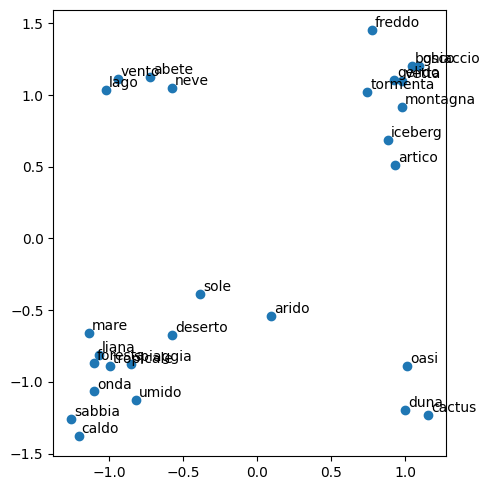

In [43]:
selected_words = bow.vocabulary
indexes = [bow.word2idx[w] for w in selected_words]
selected2d = model.vectors(selected_words)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(selected2d[:,0], selected2d[:, 1])
for i, w in enumerate(selected_words):
    ax.text(selected2d[i][0] + .02, selected2d[i][1] + .02, w)
plt.tight_layout()
plt.show()